In [1]:
# Installing the Libraries need for the experiment
# Run once, then restart the kernel
%pip install -q azure-ai-documentintelligence azure-search-documents \
    langchain langchain-openai langchain-text-splitters langchain-experimental \
    langgraph cohere ragas logfire pandas pydantic

Note: you may need to restart the kernel to use updated packages.


In [13]:
import os
from pathlib import Path
from dotenv import load_dotenv
load_dotenv(override=True)


os.environ["AZURE_DI_ENDPOINT"] = os.getenv("AZURE_DOCUMENT_INTELLIGENCE_ENDPOINT")
os.environ["AZURE_DI_KEY"] = os.getenv("AZURE_DOCUMENT_INTELLIGENCE_KEY")

os.environ["AZURE_SEARCH_ENDPOINT"] = os.getenv("AZURE_AI_SEARCH_ENDPOINT")
os.environ["AZURE_SEARCH_KEY"] = os.getenv("AZURE_AI_SEARCH_KEY")
os.environ["AZURE_SEARCH_INDEX"] = os.getenv("INDEX_NAME")

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["OPENAI_CHAT_MODEL"] = os.getenv("OPENAI_COMPLETION_DEPLOYMENT")
os.environ["OPENAI_EMBEDDING_MODEL"]= os.getenv("OPENAI_EMBEDDING_DEPLOYMENT")

os.environ["LOGFIRE_TOKEN"] = os.getenv("LOGFIRE_TOKEN")

os.environ["LANGSMITH_TRACING"] = os.getenv("LANGSMITH_TRACING")
os.environ["LANGSMITH_PROJECT"] = os.getenv("LANGSMITH_PROJECT")
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")

# Step 0 - Observability using the Logfire

In [6]:
pip install opentelemetry-instrumentation-httpx

Note: you may need to restart the kernel to use updated packages.


In [14]:
import logfire

logfire.configure(service_name="hr-rag-pipeline")
logfire.instrument_openai() # This traces OpenAI API calls
logfire.instrument_httpx() # This traces HTTPX requests

[ERROR] `high_res_size` is part of DeepseekVLHybridImageProcessorKwargs, but not documented. Make sure to add it to the docstring of the function in /Users/manuvenugopalan/Documents/Programming/Interview_Experiment/.venv/lib/python3.13/site-packages/transformers/models/deepseek_vl_hybrid/image_processing_pil_deepseek_vl_hybrid.py.
[ERROR] `high_res_size` is part of DeepseekVLHybridImageProcessorKwargs, but not documented. Make sure to add it to the docstring of the function in /Users/manuvenugopalan/Documents/Programming/Interview_Experiment/.venv/lib/python3.13/site-packages/transformers/models/deepseek_vl_hybrid/image_processing_pil_deepseek_vl_hybrid.py.


Logfire project URL: https://logfire-eu.pydantic.dev/manuaberdeen88/starter-project

Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


[ERROR] `min_pixels` is part of PaddleOCRVLImageProcessorKwargs, but not documented. Make sure to add it to the docstring of the function in /Users/manuvenugopalan/Documents/Programming/Interview_Experiment/.venv/lib/python3.13/site-packages/transformers/models/paddleocr_vl/image_processing_pil_paddleocr_vl.py.
[ERROR] `max_pixels` is part of PaddleOCRVLImageProcessorKwargs, but not documented. Make sure to add it to the docstring of the function in /Users/manuvenugopalan/Documents/Programming/Interview_Experiment/.venv/lib/python3.13/site-packages/transformers/models/paddleocr_vl/image_processing_pil_paddleocr_vl.py.
[ERROR] `min_pixels` is part of PaddleOCRVLImageProcessorKwargs, but not documented. Make sure to add it to the docstring of the function in /Users/manuvenugopalan/Documents/Programming/Interview_Experiment/.venv/lib/python3.13/site-packages/transformers/models/paddleocr_vl/image_processing_pil_paddleocr_vl.py.
[ERROR] `max_pixels` is part of PaddleOCRVLImageProcessorKwar

# Step 1 - Extract the document with Azure Document Intelligence

In [15]:
from azure.ai.documentintelligence import DocumentIntelligenceClient
from azure.core.credentials import AzureKeyCredential


Azure_Document_Client = DocumentIntelligenceClient(endpoint = os.environ["AZURE_DI_ENDPOINT"],
                                                   credential=AzureKeyCredential(os.environ["AZURE_DI_KEY"]))

# Static metadata an HR team would maintain per document (in production: a content database)
DOC_REGISTRY = {
    "uk_annual_leave_policy.pdf":      {"jurisdiction": "UK",      "effective_date": "2026-04-01"},
    "ireland_annual_leave_policy.pdf": {"jurisdiction": "Ireland", "effective_date": "2026-01-01"},
    "uk_disciplinary_policy.pdf":      {"jurisdiction": "UK",      "effective_date": "2026-06-01"},
    "ireland_remote_work_policy.pdf": {"jurisdiction": "Ireland", "effective_date": "2026-03-01"},
    "remote_hybrid_working_policy.pdf": {"jurisdiction": "UK", "effective_date": "2026-05-01"},
    "uk_employment_contract.pdf": {"jurisdiction": "UK", "effective_date": "2026-07-01"},
    "uk_working_time_guidance.pdf": {"jurisdiction": "UK", "effective_date": "2026-08-01"}
}



In [16]:
import json

CACHE_FILE = Path("extracted_cache.json")
DOCS_DIR = Path("documents")
sorted(p.name for p in DOCS_DIR.glob("*.pdf"))

if CACHE_FILE.exists():
    # ---- Load from cache: Document Intelligence is NOT called at all ----
    extracted = json.loads(CACHE_FILE.read_text(encoding="utf-8"))
else:
    # ---- First run only: call Document Intelligence, then save ----
    extracted = []
    for pdf_path in sorted(DOCS_DIR.glob("*.pdf")):
        with logfire.span("extract {file}", file=pdf_path.name):
            with open(pdf_path, "rb") as f:
                poller = Azure_Document_Client.begin_analyze_document(
                    "prebuilt-layout", body=f, output_content_format="markdown"
                )
            result = poller.result()
            pages = result.content.split("<!-- PageBreak -->")
            for page_num, page_md in enumerate(pages, start=1):
                extracted.append({
                    "source_file": pdf_path.name,
                    "page": page_num,
                    "markdown": page_md.strip(),
                    **DOC_REGISTRY[pdf_path.name],
                })
    CACHE_FILE.write_text(json.dumps(extracted, indent=2, ensure_ascii=False),
                          encoding="utf-8")

[(e["source_file"], e["page"], len(e["markdown"])) for e in extracted]

[('ireland_annual_leave_policy.pdf', 1, 1502),
 ('ireland_remote_work_policy.pdf', 1, 670),
 ('remote_hybrid_working_policy.pdf', 1, 1420),
 ('uk_annual_leave_policy.pdf', 1, 1769),
 ('uk_disciplinary_policy.pdf', 1, 1488),
 ('uk_disciplinary_policy.pdf', 2, 197),
 ('uk_employment_contract.pdf', 1, 1313),
 ('uk_working_time_guidance.pdf', 1, 986)]

# Step 2 - Two stage chunking

In [17]:
from langchain_text_splitters import MarkdownHeaderTextSplitter
from langchain_openai import OpenAI, OpenAIEmbeddings
from langchain_experimental.text_splitter import SemanticChunker

embedding = OpenAIEmbeddings(model=os.environ["OPENAI_EMBEDDING_DEPLOYMENT"])

header_splitter = MarkdownHeaderTextSplitter(
                    headers_to_split_on=[("#", "h1"), ("##", "h2"), ("###", "h3")]
                )

semantic_chunker = SemanticChunker(
                        embeddings=embedding,
                        breakpoint_threshold_type="percentile", 
                        breakpoint_threshold_amount=90
                     )

In [18]:
MAX_SECTION_CHARS = 1200
chunks = []
for entry in extracted:
    for doc in header_splitter.split_text(entry["markdown"]):
        section = " > ".join(v for k, v in doc.metadata.items())  # e.g. "2. Stages > 2.4 Dismissal"
        texts = ([doc.page_content] if len(doc.page_content) <= MAX_SECTION_CHARS
                 else semantic_chunker.split_text(doc.page_content))
        for text in texts:
            chunks.append({
                "id": f"chunk-{len(chunks):04d}",
                "content": f"{section}\n{text}" if section else text,
                "section": section or "Preamble",
                "source_file": entry["source_file"],
                "page": entry["page"],
                "jurisdiction": entry["jurisdiction"],
                "effective_date": entry["effective_date"],
            })

len(chunks), chunks[3]

(41,
 {'id': 'chunk-0003',
  'content': "Annual Leave Policy (Republic of Ireland) > 3. Carry-Over and Payment in Lieu\nAnnual leave should normally be taken within the leave year. With the employee's consent, leave\nmay be taken within 6 months of the following year. Payment in lieu of untaken statutory leave is\nonly permitted on termination of employment.",
  'section': 'Annual Leave Policy (Republic of Ireland) > 3. Carry-Over and Payment in Lieu',
  'source_file': 'ireland_annual_leave_policy.pdf',
  'page': 1,
  'jurisdiction': 'Ireland',
  'effective_date': '2026-01-01'})

# Step 3 - Azure AI Search

In [19]:
os.environ["AZURE_SEARCH_ENDPOINT"]

'https://manu-ai-search-dev.search.windows.net'

In [20]:
os.environ["AZURE_SEARCH_INDEX"]

'hr-policies-hybrid'

In [21]:
# This step will create a index in Azure Cognitive Search
# We can see this in the portal, Under the Search management section -> Indexes

from azure.search.documents.indexes import SearchIndexClient
from azure.search.documents.indexes.models import (
    SearchIndex, SimpleField, SearchableField, SearchField, SearchFieldDataType,
    VectorSearch, HnswAlgorithmConfiguration, VectorSearchProfile,
    SemanticConfiguration, SemanticPrioritizedFields, SemanticField, SemanticSearch,
)

index_client = SearchIndexClient(
    os.environ["AZURE_SEARCH_ENDPOINT"], AzureKeyCredential(os.environ["AZURE_SEARCH_KEY"])
)

index = SearchIndex(
    name=os.environ["AZURE_SEARCH_INDEX"],
    fields=[
        SimpleField(name="id", type=SearchFieldDataType.String, key=True),
        SearchableField(name="content", type=SearchFieldDataType.String, analyzer_name="en.microsoft"),
        SearchableField(name="section", type=SearchFieldDataType.String),
        SimpleField(name="source_file", type=SearchFieldDataType.String, filterable=True),
        SimpleField(name="page", type=SearchFieldDataType.Int32, filterable=True),
        SimpleField(name="jurisdiction", type=SearchFieldDataType.String, filterable=True, facetable=True),
        SimpleField(name="effective_date", type=SearchFieldDataType.String, filterable=True, sortable=True),
        SearchField(name="content_vector", type=SearchFieldDataType.Collection(SearchFieldDataType.Single),
                    vector_search_dimensions=3072, vector_search_profile_name="v-profile"),
    ],
    vector_search=VectorSearch(
        algorithms=[HnswAlgorithmConfiguration(name="hnsw")],
        profiles=[VectorSearchProfile(name="v-profile", algorithm_configuration_name="hnsw")],
    ),
    semantic_search=SemanticSearch(configurations=[
        SemanticConfiguration(
            name="sem-config",
            prioritized_fields=SemanticPrioritizedFields(
                title_field=SemanticField(field_name="section"),
                content_fields=[SemanticField(field_name="content")],
            ),
        )
    ]),
)

index_client.create_or_update_index(index)
index_client.get_index(os.environ["AZURE_SEARCH_INDEX"]).name

'hr-policies-hybrid'

In [22]:
# Determine the dimensionality of the embedding vectors used by the model
# Azure AI search uses the Diamension of 3072 for the embedding vectors
# Either we have to use embedding large model or we need to adjust the search index configuration accordingly
EMBED_DIMS = len(embedding.embed_query("probe")) 

14:47:08.308 Embedding Creation with 'text-embedding-3-large' [LLM]


In [23]:
# This step will upload the embedded document chunks to the Azure Cognitive Search index

from azure.search.documents import SearchClient

search_client = SearchClient(
    os.environ["AZURE_SEARCH_ENDPOINT"], 
    os.environ["AZURE_SEARCH_INDEX"],
    AzureKeyCredential(os.environ["AZURE_SEARCH_KEY"])
)

# Embed all chunks in one batched call, then upload
vectors = embedding.embed_documents([c["content"] for c in chunks])
docs = [{**c, "content_vector": v} for c, v in zip(chunks, vectors)]
upload_result = search_client.upload_documents(docs)

sum(r.succeeded for r in upload_result), "of", len(docs), "chunks indexed" 

14:47:13.777 Embedding Creation with 'text-embedding-3-large' [LLM]


(41, 'of', 41, 'chunks indexed')

# Step 4 - Reranking the chunks

In [24]:
from azure.search.documents import SearchClient 
from azure.search.documents.models import VectorizedQuery
from azure.core.credentials import AzureKeyCredential

In [25]:
def semantic_hybrid_search(query: str, jurisdiction: str | None = None,
                           top: int = 5) -> list[dict]:

    vq = VectorizedQuery(vector=embedding.embed_query(query), k_nearest_neighbors=20,fields="content_vector")
    
    results = search_client.search(
        search_text = query,                                # BM25
        vector_queries= [vq],                               # Vector search
        filter=f"jurisdiction eq '{jurisdiction}'" if jurisdiction else None,
        query_type="semantic",                          # turns the reranker ON
        semantic_configuration_name="sem-config",       # the config you already defined
        select=["id", "content", "section", "source_file", "page", "jurisdiction"],
        top=top,
    )
    return [dict(r) | {"rerank_score": r["@search.reranker_score"]} for r in results]

In [26]:
# Quick sanity check: the filter must keep Ireland results out
test = semantic_hybrid_search("how many days annual leave", "UK", top=5)
[(t["source_file"], t["section"], round(t["rerank_score"], 3)) for t in test]

14:47:23.931 Embedding Creation with 'text-embedding-3-large' [LLM]


[('uk_employment_contract.pdf',
  'Sample UK Employment Contract > 3. Annual Leave',
  3.03),
 ('uk_annual_leave_policy.pdf',
  'Annual Leave Policy (United Kingdom) > 1. Statutory Entitlement',
  2.965),
 ('uk_annual_leave_policy.pdf',
  'Annual Leave Policy (United Kingdom) > 5. Worked Examples',
  2.894),
 ('uk_annual_leave_policy.pdf',
  'Annual Leave Policy (United Kingdom) > 4. Notice Requirements for Booking Leave',
  2.686),
 ('uk_annual_leave_policy.pdf',
  'Annual Leave Policy (United Kingdom) > 2. Leave Year and Carry-Over',
  2.675)]

# Step 5 - LangGraph Multi Agent Orchestration

In [27]:
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END

In [28]:
os.environ["OPENAI_CHAT_MODEL"]

'gpt-5.6-terra'

In [29]:
llm = ChatOpenAI(model=os.environ["OPENAI_CHAT_MODEL"], temperature=0)

In [30]:
class RAGState(TypedDict, total=False):
    question: str
    search_query: str
    jurisdiction: str | None
    sources: list[dict]
    answer: str
    citations: list[dict]
    route: str            # "answered" | "clarify" | "refused"
    verified: bool

class QueryAnalysis(BaseModel):
    """Structured output of the understand step."""
    clear: bool = Field(description="True if the question can be searched as-is")
    jurisdiction: Literal["UK", "Ireland"] | None = Field(
        description="Jurisdiction if stated or clearly implied, else null")
    search_query: str = Field(description="Cleaned, self-contained search query")
    clarifying_question: str | None = Field(
        description="If not clear: the ONE question to ask the user back")

class SourceGrade(BaseModel):
    """Structured output of the grading step."""
    sufficient: bool = Field(description="True if the sources settle the question")
    missing_facts: str | None = Field(description="If insufficient: what is missing")

In [31]:

def understand(state: RAGState) -> RAGState:
    analysis = llm.with_structured_output(QueryAnalysis).invoke(
        "You analyse questions for an HR policy assistant covering UK and Ireland.\n"
        "A question is NOT clear if the jurisdiction is needed but absent, or if it is too "
        "vague to search. Never guess the jurisdiction.\n\n"
        f"Question: {state['question']}"
    )
    if not analysis.clear:
        return {"route": "clarify", "answer": analysis.clarifying_question}
    return {"route": "search", "search_query": analysis.search_query,
            "jurisdiction": analysis.jurisdiction}


def retrieve(state: RAGState) -> RAGState:
    return {"sources": semantic_hybrid_search(state["search_query"],
                                              state.get("jurisdiction"), top=5)}


def grade(state: RAGState) -> RAGState:
    numbered = "\n\n".join(f"[S{i+1}] {s['content']}" for i, s in enumerate(state["sources"]))
    verdict = llm.with_structured_output(SourceGrade).invoke(
        "Do these policy extracts contain enough information to answer the question "
        "completely? Judge strictly — partial coverage is insufficient.\n\n"
        f"Question: {state['question']}\n\nExtracts:\n{numbered}"
    )
    if not verdict.sufficient:
        return {"route": "refused",
                "answer": "I can't answer this reliably from the policy library. "
                          f"Missing: {verdict.missing_facts}"}
    return {"route": "generate"}


def generate(state: RAGState) -> RAGState:
    numbered = "\n\n".join(f"[S{i+1}] ({s['source_file']}, p.{s['page']}, {s['section']})\n"
                             f"{s['content']}" for i, s in enumerate(state["sources"]))
    answer = llm.invoke(
        "Answer using ONLY the numbered sources. Every sentence that states a fact must end "
        "with its citation tag like [S1] or [S2][S3]. If a detail is not in the sources, do "
        "not state it. Be concise and practical.\n\n"
        f"Question: {state['question']}\n\nSources:\n{numbered}"
    ).content
    return {"answer": answer, "route": "answered"}


def verify(state: RAGState) -> RAGState:
    import re
    cited_ids = {int(m) for m in re.findall(r"\[S(\d+)\]", state["answer"])}
    valid = bool(cited_ids) and cited_ids <= set(range(1, len(state["sources"]) + 1))
    citations = [{"tag": f"S{i}", **{k: state["sources"][i-1][k]
                  for k in ("source_file", "page", "section")}} for i in sorted(cited_ids)]
    return {"verified": valid, "citations": citations}

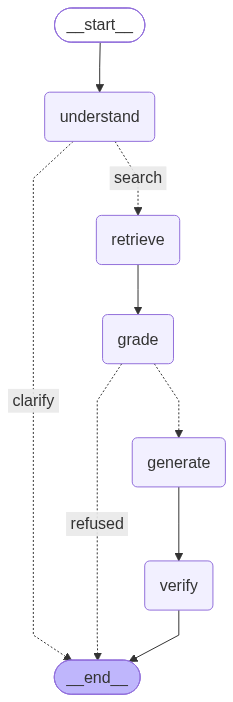

In [32]:
graph = StateGraph(RAGState)
graph.add_node("understand", understand)
graph.add_node("retrieve", retrieve)
graph.add_node("grade", grade)
graph.add_node("generate", generate)
graph.add_node("verify", verify)

graph.add_edge(START, "understand")
graph.add_conditional_edges("understand", lambda s: s["route"],
                            {"clarify": END, "search": "retrieve"})
graph.add_edge("retrieve", "grade")
graph.add_conditional_edges("grade", lambda s: s["route"],
                            {"refused": END, "generate": "generate"})
graph.add_edge("generate", "verify")
graph.add_edge("verify", END)

app = graph.compile()

from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

In [33]:
# 1) Clear question -> full pipeline with citations
with logfire.span("query: clear"):
    clear_run = app.invoke({"question": "How many days of annual leave does a full-time UK employee get?"})
print(clear_run["answer"])
clear_run["citations"], clear_run["verified"]

14:47:35.082 query: clear
14:47:35.136   Chat Completion with 'gpt-5.6-terra' [LLM]
14:47:37.721   Embedding Creation with 'text-embedding-3-large' [LLM]
14:47:39.476   Chat Completion with 'gpt-5.6-terra' [LLM]
14:47:41.115   Chat Completion with 'gpt-5.6-terra' [LLM]
A full-time UK employee is entitled to a minimum of 5.6 weeks, or 28 days, of paid annual leave per leave year; this may include the 8 English bank holidays. [S1]


([{'tag': 'S1',
   'source_file': 'uk_annual_leave_policy.pdf',
   'page': 1,
   'section': 'Annual Leave Policy (United Kingdom) > 1. Statutory Entitlement'}],
 True)

In [34]:
# 2) Vague question -> the graph asks for the missing fact instead of guessing
with logfire.span("query: vague"):
    vague_run = app.invoke({"question": "How much notice do I need to give for booking leave?"})
vague_run["route"], vague_run["answer"]

14:47:54.387 query: vague
14:47:54.392   Chat Completion with 'gpt-5.6-terra' [LLM]


('clarify', 'Are you employed in the UK or Ireland?')

In [35]:
# 3) Out-of-scope question -> grounded refusal that names what is missing
with logfire.span("query: out-of-scope"):
    oos_run = app.invoke({"question": "What is the statutory sick pay rate per week in the UK?"})
oos_run["route"], oos_run["answer"]

14:48:06.720 query: out-of-scope
14:48:06.723   Chat Completion with 'gpt-5.6-terra' [LLM]
14:48:09.672   Embedding Creation with 'text-embedding-3-large' [LLM]
14:48:10.439   Chat Completion with 'gpt-5.6-terra' [LLM]


('refused',
 "I can't answer this reliably from the policy library. Missing: The extracts do not state the UK statutory sick pay (SSP) weekly rate. They only address annual leave and a working-time guidance reference; an authoritative SSP rate (and, if date-sensitive, the applicable period/effective date) is required.")

In [36]:
import pandas as pd

pd.DataFrame(clear_run["citations"])

,tag,source_file,page,section
0,S1,uk_annual_leave_policy.pdf,1,Annual Leave Policy (United Kingdom) > 1. Stat...


# Evaluation using the Ragas

In [37]:
from ragas import evaluate, EvaluationDataset
from ragas.dataset_schema import SingleTurnSample
from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper

/var/folders/vc/dpysxl655v97p8sm030pf_v00000gn/T/ipykernel_30913/2328066192.py:3: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
/var/folders/vc/dpysxl655v97p8sm030pf_v00000gn/T/ipykernel_30913/2328066192.py:3: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
/var/folders/vc/dpysxl655v97p8sm030pf_v00000gn/T/ipykernel_30913/2328066192.py:3: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'raga

In [38]:
# Ground truth set for questions and references regarding UK and Ireland employment policies

gold_set = [
    {"question": "How many days of annual leave does a full-time UK employee get?",
     "reference": "Full-time UK employees get a minimum of 5.6 weeks, i.e. 28 days of paid "
                  "annual leave per year, which may include the 8 bank holidays."},
    {"question": "How many public holidays are there in Ireland and are they part of annual leave?",
     "reference": "Ireland has 10 public holidays and they are separate from, and additional to, "
                  "the 4 working weeks of annual leave."},
    {"question": "What happens if a UK employee is sick during booked annual leave?",
     "reference": "With a fit note covering the period, the sick days are reclassified as sick "
                  "leave and the annual leave days are returned to the employee's balance."},
    {"question": "How long does a final written warning stay active in the UK disciplinary procedure?",
     "reference": "A final written warning remains active for 12 months."},
]

In [ ]:
samples = []

for item in gold_set:
    run = app.invoke({"question": item["question"]})
    samples.append(SingleTurnSample(
        user_input=item["question"],
        response=run.get("answer", ""),
        retrieved_contexts=[s["content"] for s in run.get("sources", [])],
        reference=item["reference"],
    ))

judge_llm = ChatOpenAI(azure_deployment="gpt-4o-mini", temperature=0)
eval_result = evaluate(
    EvaluationDataset(samples=samples),
    metrics=[faithfulness, answer_relevancy, context_precision, context_recall],
    llm=LangchainLLMWrapper(judge_llm),
    embeddings=LangchainEmbeddingsWrapper(embedding),
)
eval_result.to_pandas()[["user_input", "faithfulness", "answer_relevancy",
                         "context_precision", "context_recall"]]

14:54:04.820 Chat Completion with 'gpt-5.6-terra' [LLM]


BadRequestError: Error code: 400 - {'error': {'message': "Unsupported value: 'temperature' does not support 0.01 with this model. Only the default (1) value is supported.", 'type': 'invalid_request_error', 'param': 'temperature', 'code': 'unsupported_value'}}